In the name of God

# **CA2: Boosted Trees for Feature Generation in SVM/LDA**

Seyed Mani Mirshabani
801801080

In this homework we are going to implement a classification pipeline and use the breast cancer wisconsin dataset to preform data preprocessing, feature engineering (using gradient boosting), and classification with SVM and LDA.

## 1. Understanding the Dataset

### 1.1. Downloading the Dataset

According to the host website of the dataset (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) the dataset can be downloaded with the following commands: (first however we need to install the ucimlrepo library with "pip install ucimlrepo")

In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

cancer_dataset = pd.concat([X, y], axis=1)
cancer_dataset.rename(columns={'Diagnosis': 'diagnosis'}, inplace=True)

### 1.2. Dataset Overview

In [2]:
cancer_dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [3]:
cancer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

In [4]:
cancer_dataset.shape

(569, 31)

As we can see the dataset contains 569 instances with 30 numerical features which describe a tumor (such as radios, texture, ...). The target valuable is the diagnosis which states wether or not a tumor is malignant.

According to the website the features were extracted from digitized images of fine needle aspirates (FNA) of breast masses.

### 1.3. Target Variable

As stated earlier the target variable shows weather the tumor is malignant (M) or benign (B), we will use this to train the model to be able to predict the state of the tumor.

In [5]:
cancer_dataset.diagnosis.value_counts

<bound method IndexOpsMixin.value_counts of 0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object>

### 4.1. Feature Analysis

As we saw earlier the dataset has 30 numerical features which according to the description is grouped as follows:

- **First 10 features:** Mean values of cell properties.  
- **Second 10 features:** Standard deviation (std) values of the same properties.  
- **Final 10 features:** Worst (largest) values recorded.  

Now we will take a quick look at the statistical properties of different columns (such ast their mean, std, etc)

In [6]:
cancer_dataset.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 1.5. Exploratory Data Analysis

In this section we will be performing EDA, we will:

1. Visualize feature distributions (and find the outliers)
2. Check correlations with heatmap
3. Draw pair plots

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

#### 1.5.1. Feature distributions & plots

In [8]:
feature_cols = cancer_dataset.columns.drop('diagnosis')

suffix_map = {'1': 'Mean', '2': 'STD', '3': 'Worst'}

def get_clean_title(col_name):
    match = re.match(r"([a-zA-Z_]+)(\d)$", col_name)
    if match:
        base_name, suffix = match.groups()
        clean_suffix = suffix_map.get(suffix, '')
        return f'Distribution of {clean_suffix} {base_name.replace("_", " ").title()}'
    return col_name

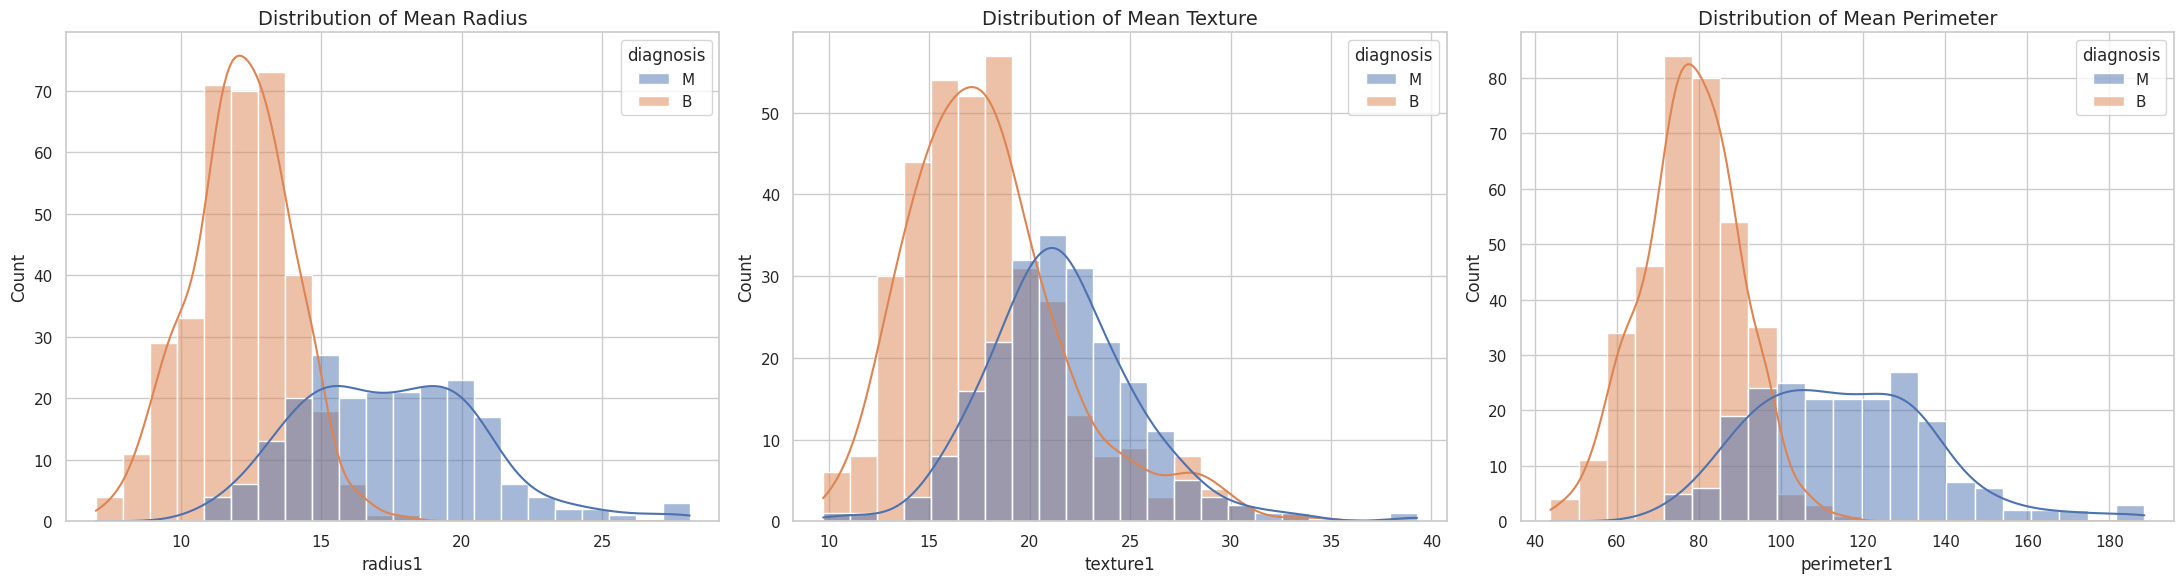

In [ ]:
batch_1_features = feature_cols[0:3]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_1_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

As we can see overall the malignant (M) class had a higher value in terms of all three features, we can also see that the distribution of benign (B) class was almost normal but the malignant class (in radius and perimeter) wasn't this way.

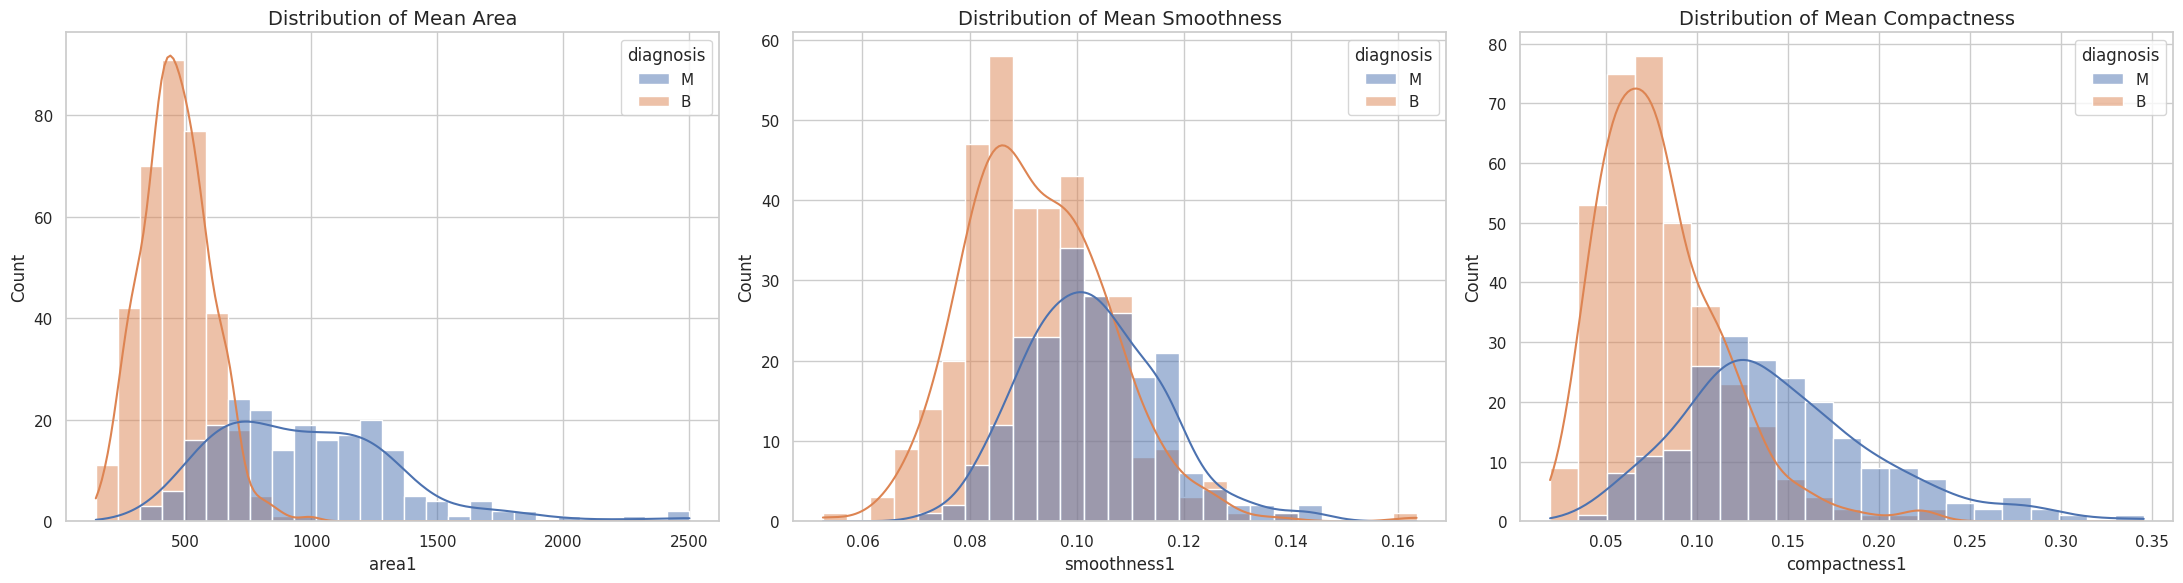

In [ ]:
batch_2_features = feature_cols[3:6]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_2_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

In this batch we can see that the difference in distribution of mean area and mean compactness is quite significant between the two classes which suggests these two features could be quite useful. It's not quite the same with the other feature (mean smoothness) and both classes have rather similar distributions!

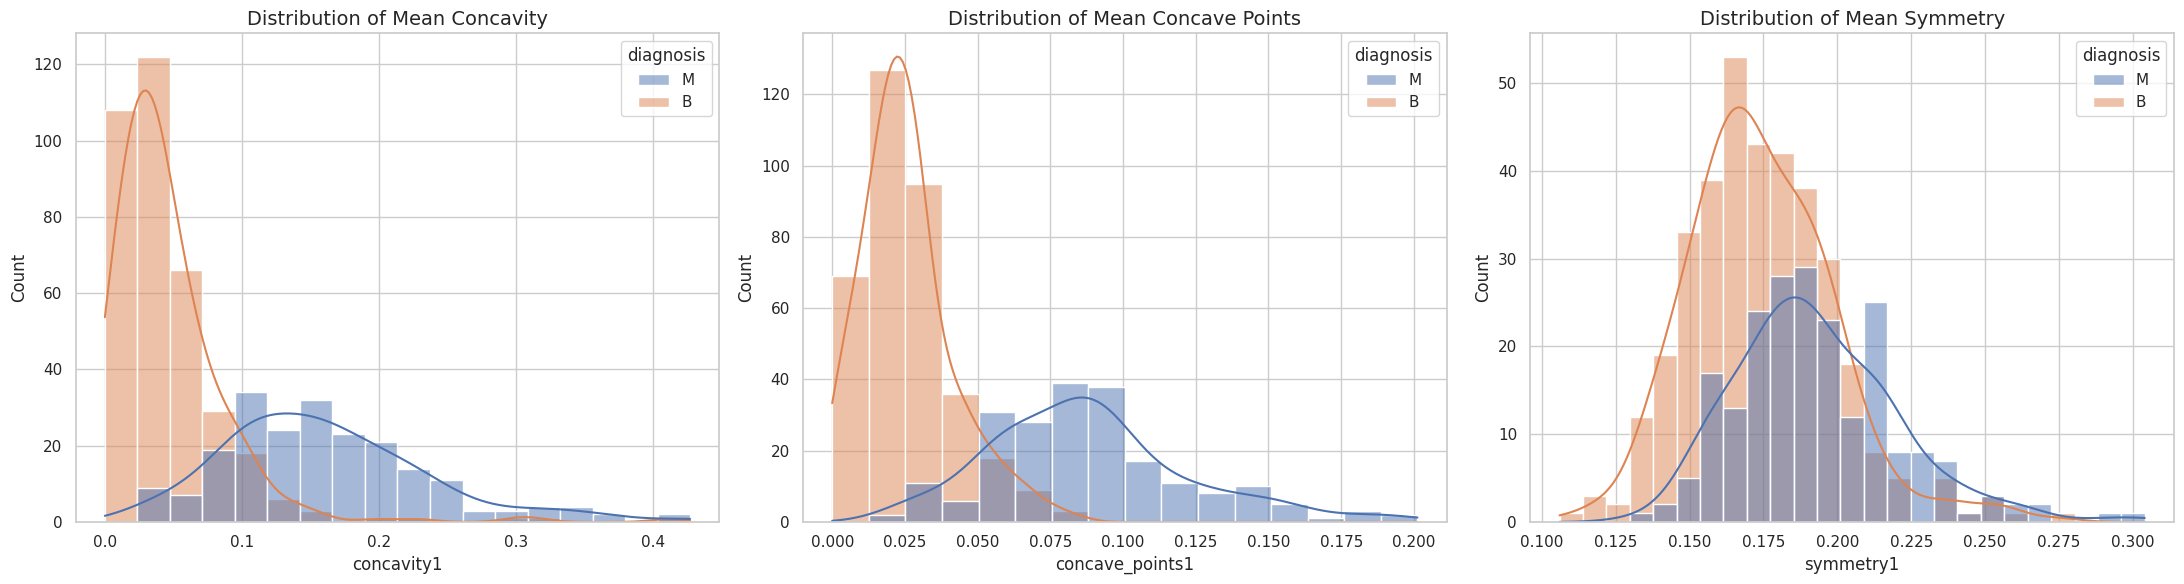

In [ ]:
batch_3_features = feature_cols[6:9]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_3_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

Again we see a high shift between the B and M class for two of the features (mean concavity and mean concave points, which according to their name appear to relate to roughly the same concept), meaning these two can be valuable features for our classification algorithms.

It's not the same with the mean symmetry class however and the distribution of the two classes are quite similar here!

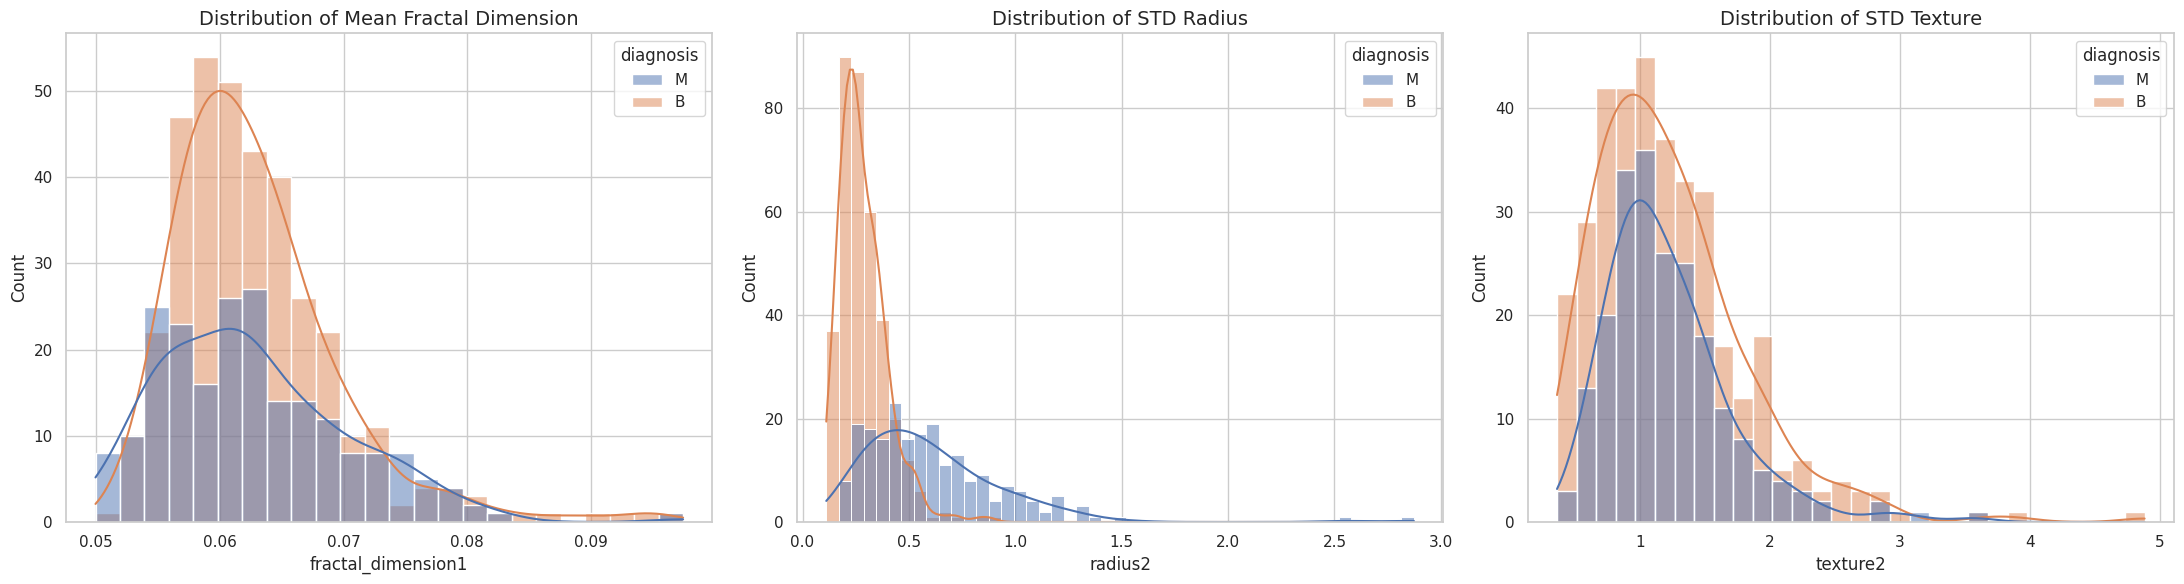

In [ ]:
batch_4_features = feature_cols[9:12]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_4_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

For these three features we can see that the difference in distribution is quite visible in STD Radius but the other two are quite similar (with the STD Texture having almost identical distribution for both classes)

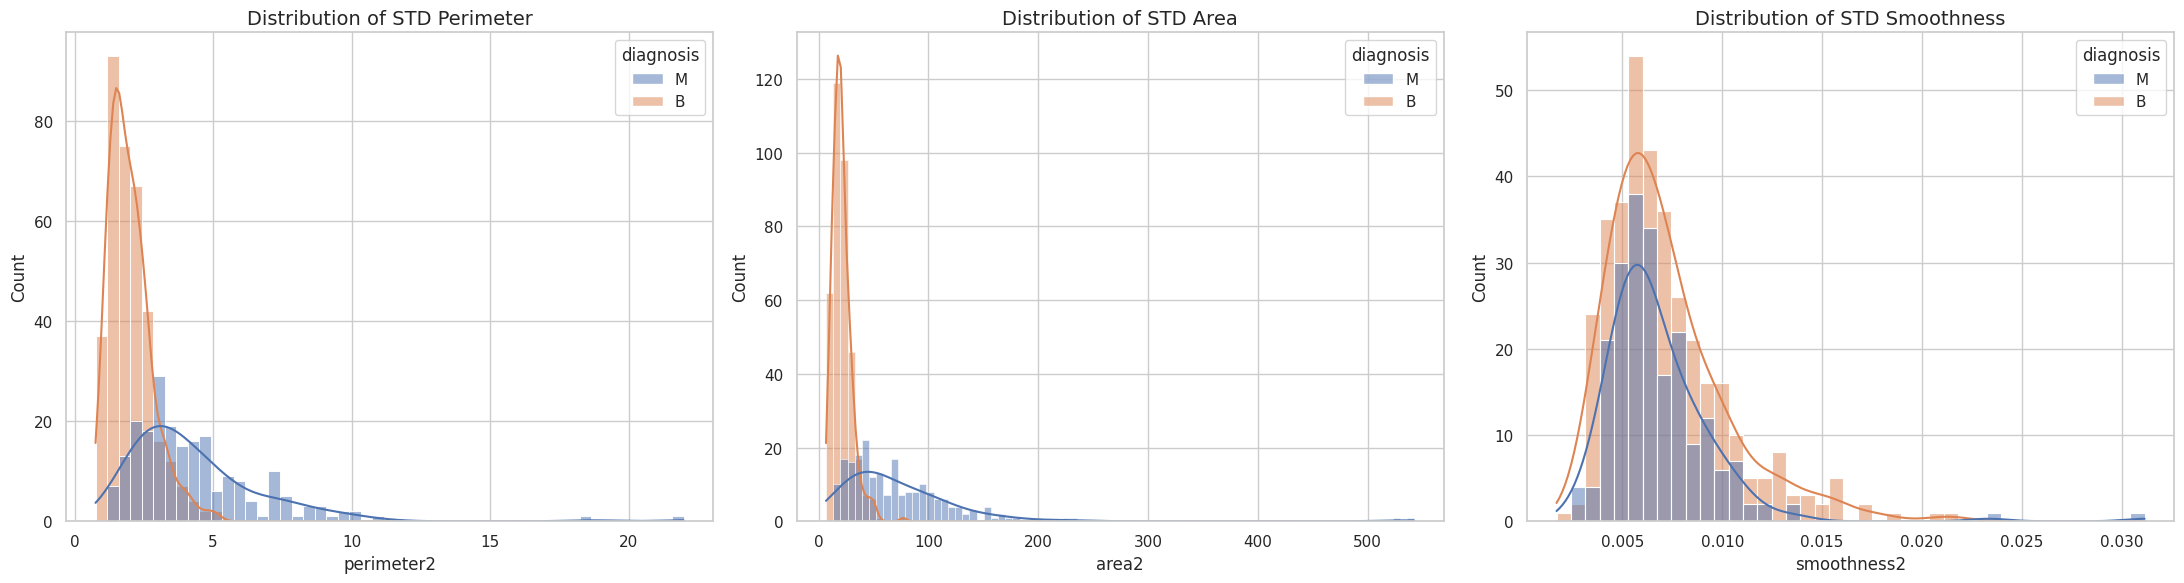

In [ ]:
batch_5_features = feature_cols[12:15]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_5_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

Here we can see the benign tumors have a much narrower std perimeter and area (which are two highly related features) compared to malignant tumors, showing that benign tumors probably have a more structured form.

the std of smoothness of the two classes are quite similar however, so this is probably not a useful feature and if we were to manually pick some features (and not use methods like PCA) we would probably omit this one.

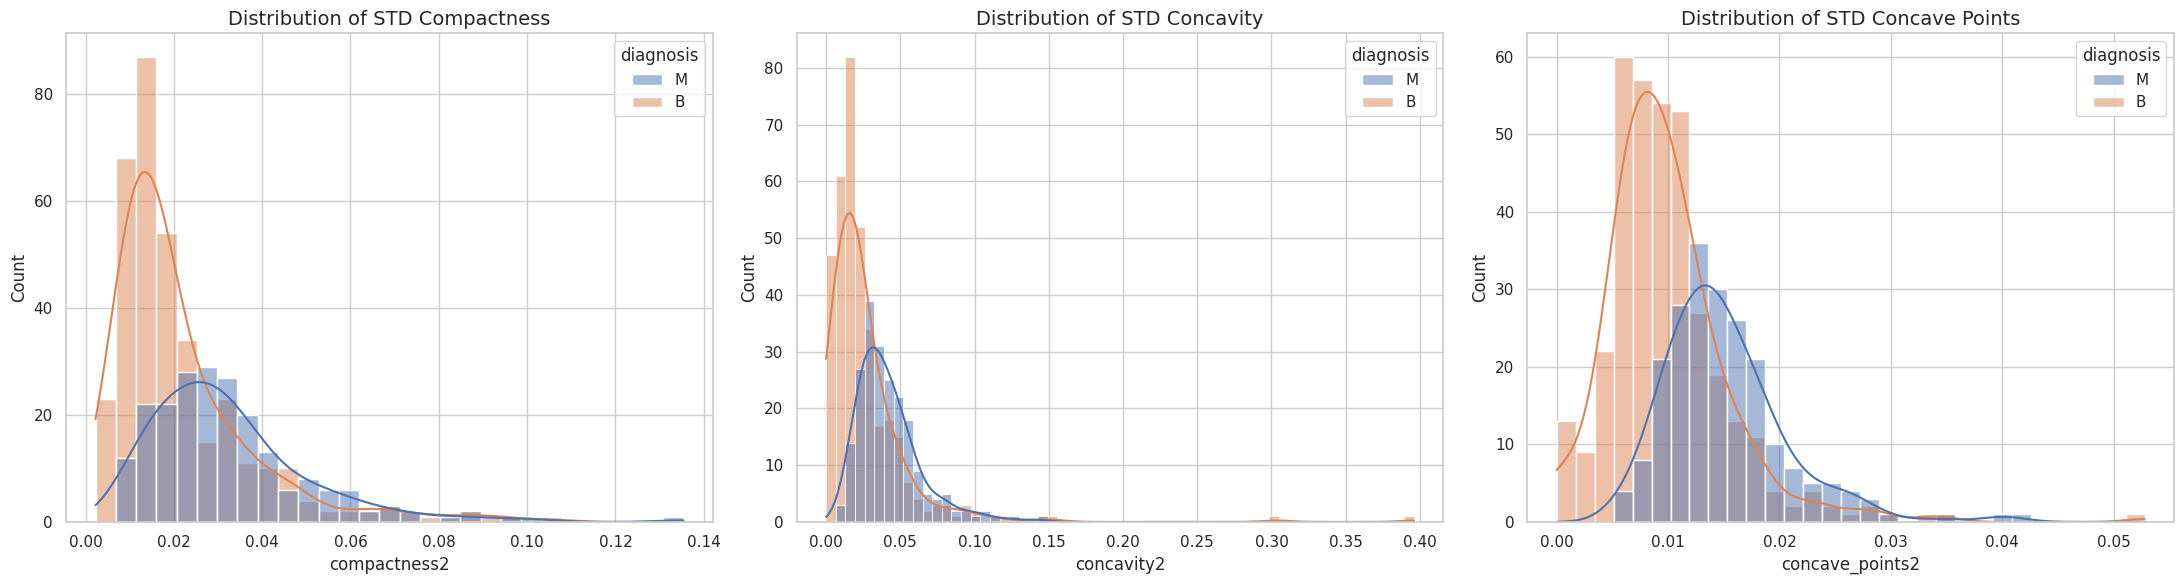

In [ ]:
batch_6_features = feature_cols[15:18]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_6_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

From these three features we can see that while the distribution of std compactness is somewhat different between the two classes, std concavity and stc concave points (which again probably relate to the same concept and are highly correlated) are have a similar distribution among the two classes.

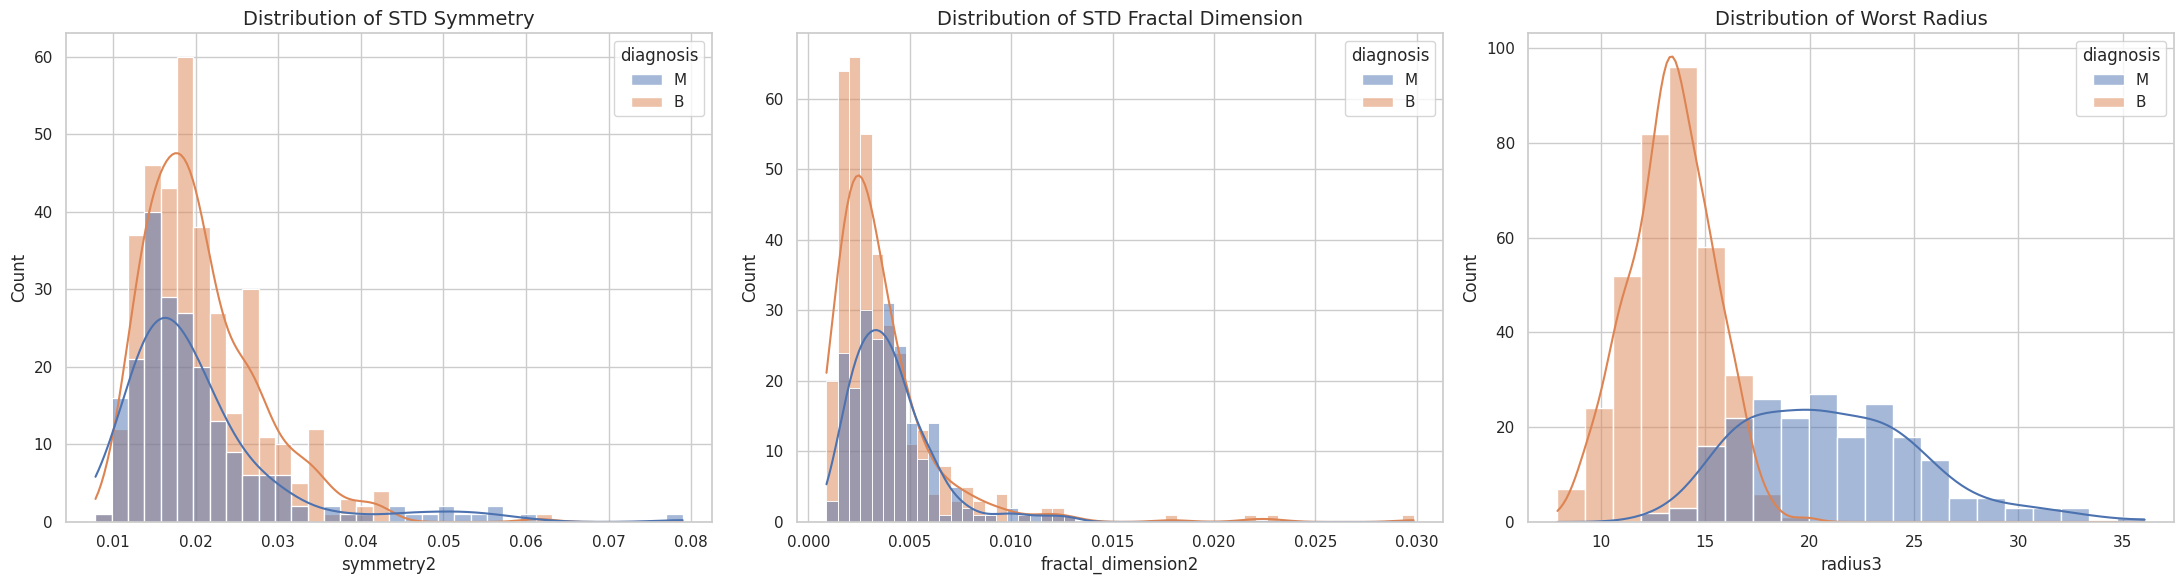

In [ ]:
batch_7_features = feature_cols[18:21]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_7_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(get_clean_title(feature), fontsize=14)

plt.tight_layout()
plt.show()

With these three features we can clearly see that while the distribution of std symmetry and std fractal dimension is almost the same in the two classes, distribution of the worst radius is quite different and malignant tumors tend to have a higher worst (largest) radius

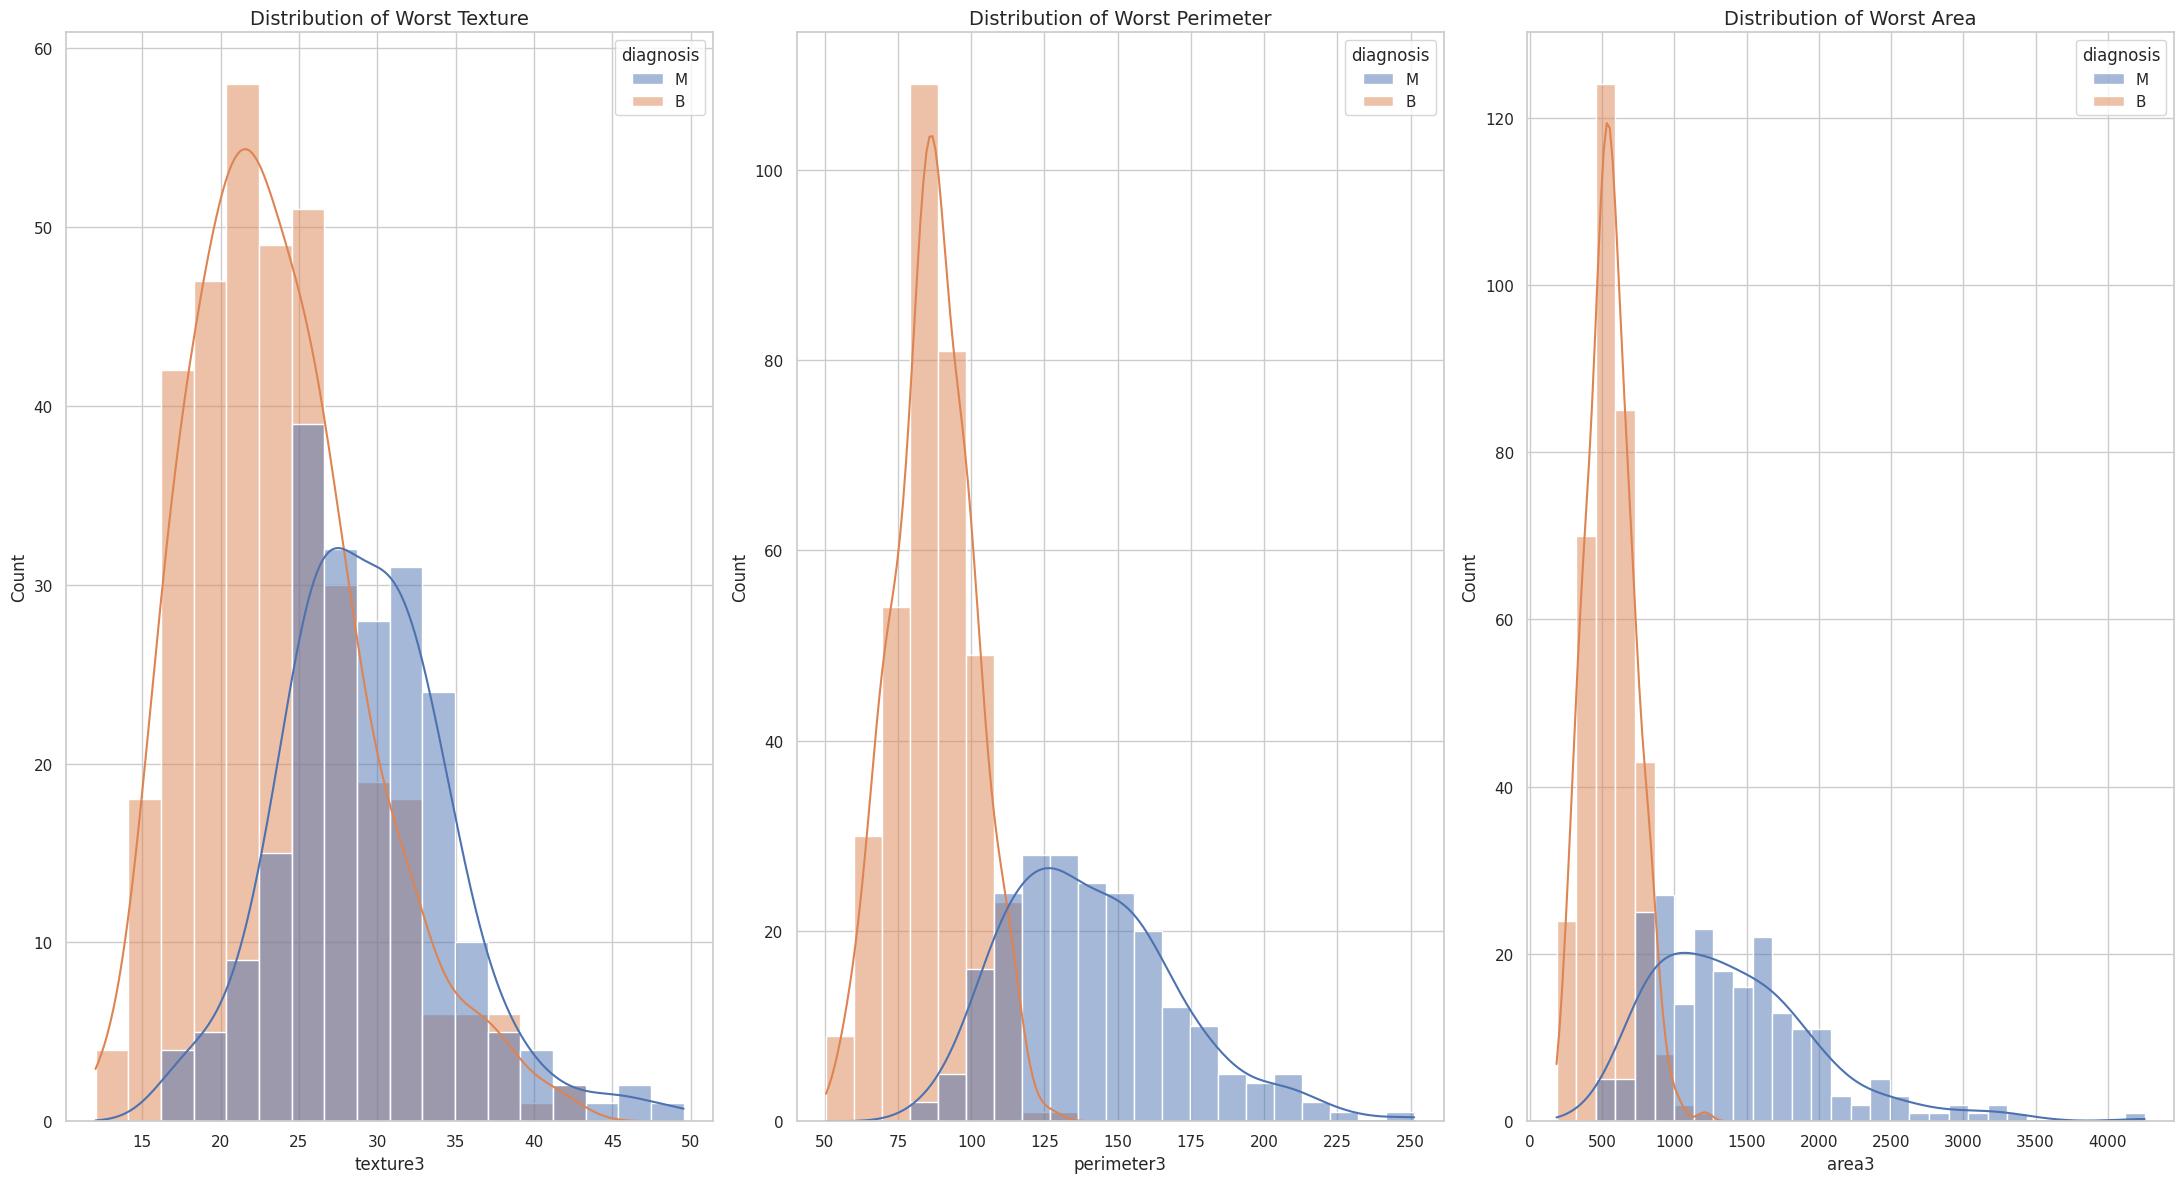

In [ ]:
batch_8_features = feature_cols[21:24]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_8_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    # Plot Box Plot on the bottom row
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[i+3])
    axes[i+3].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

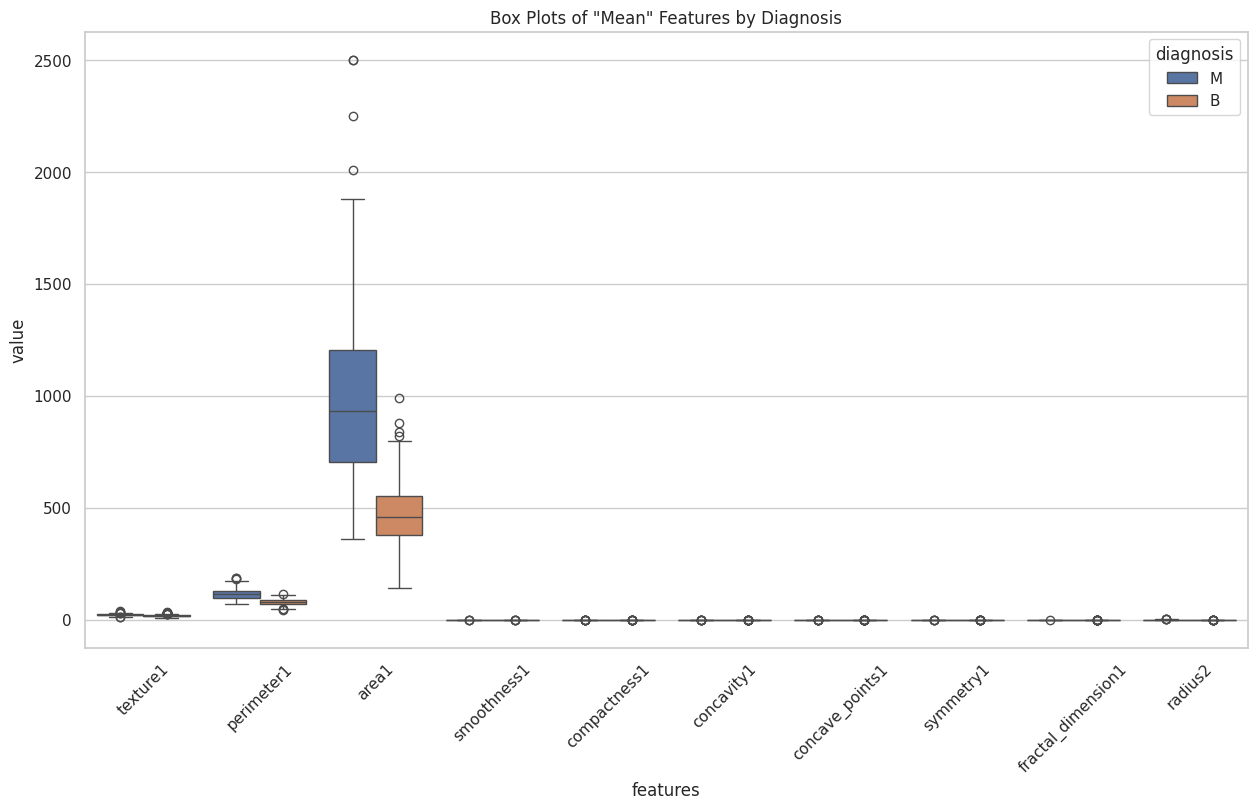

In [17]:
# To make the plot readable, let's melt the DataFrame
data_mean = cancer_dataset.iloc[:, 1:11] # Select the 10 'mean' features
data_plot = pd.concat([cancer_dataset['diagnosis'], data_mean], axis=1)
data_plot = pd.melt(data_plot, id_vars="diagnosis", 
                    var_name="features", 
                    value_name='value')

plt.figure(figsize=(15, 8))
sns.boxplot(x="features", y="value", hue="diagnosis", data=data_plot)
plt.xticks(rotation=45) # Rotate feature names for readability
plt.title('Box Plots of "Mean" Features by Diagnosis')
plt.show()